SIMPLE LINEAR REGRESSSION
divide the features based on independent and dependent features
train_test_split
standardize the data
training the model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv(r"D:\weightheight.csv")

In [3]:
df

,Weight,Height
0,45,120
1,50,130
2,60,160
3,55,155
4,45,140
5,68,168
6,70,180
7,80,190
8,88,195
9,62,162


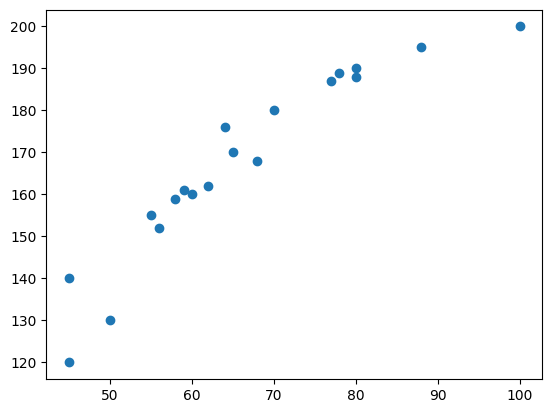

In [4]:
plt.scatter(df['Weight'],df['Height'])

In [9]:
#divide the featrue 
x=df[['Weight']]#independent
y=df['Height']#dependent

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
x_t,x_test,y_t,y_test=train_test_split(x,y,test_size=0.20,random_state=42)


In [12]:
x.shape

(19, 1)

In [13]:
x_t.shape,x_test.shape


((15, 1), (4, 1))

In [14]:
scaler=StandardScaler()
x_t=scaler.fit_transform(x_t)
x_test=scaler.transform(x_test) 


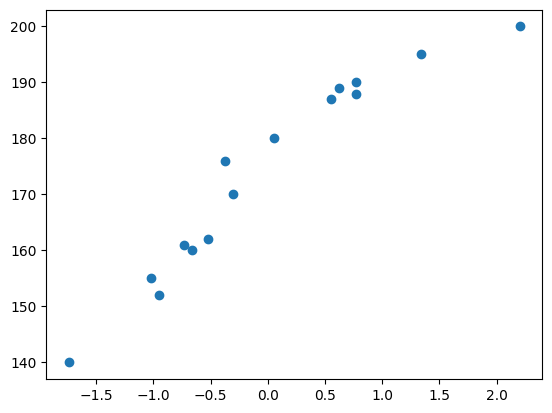

In [15]:
plt.scatter(x_t,y_t)

In [19]:
#train the model
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x_t,y_t)
reg.coef_
print("the slope of weight",reg.coef_)
print('the intercept',reg.intercept_)
y_pred=reg.predict(x_t)

the slope of weight [16.69868017]
the intercept 173.66666666666666


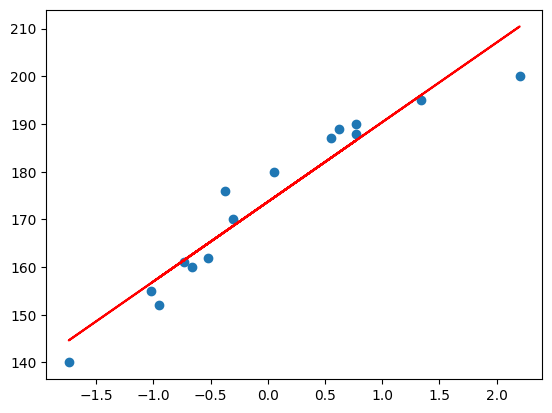

In [20]:
plt.scatter(x_t,y_t)
plt.plot(x_t,reg.predict(x_t),'r')

Prediction of train data
1.predicted o/p =intercept+coef(weight)
2.y_pre_train=172+16(x_t)

prediction of test data

predicted height o/p = intercept+coef_(weight)
y_pred_test=173+16(x_test)

In [21]:
y_pred=reg.predict(x_test)

In [23]:
y_pred,y_test

(array([144.62797279, 172.15091067, 160.18441594, 150.61122016]),
 0     120
 5     168
 11    159
 1     130
 Name: Height, dtype: int64)

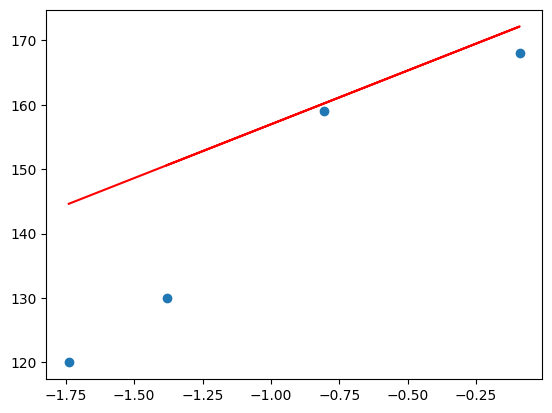

In [25]:
plt.scatter(x_test,y_test)
plt.plot(x_test,reg.predict(x_test),'r')

In [27]:
#performance metrics
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(mse)
print(mae)
print(score)

262.49808520916724
12.643629889989498
0.3323844598081901


In [28]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

-0.0014233102877148074

In [29]:
reg

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[16.7]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,173.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.87]


In [30]:
#new data pt with w =80
scaled_w=scaler.transform([[80]])
scaled_w

d:\ml\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.76916484]])

In [ ]:
print("the height for the 80 kr", reg.predict([scaled_w[0]]))

array([186.51070434])

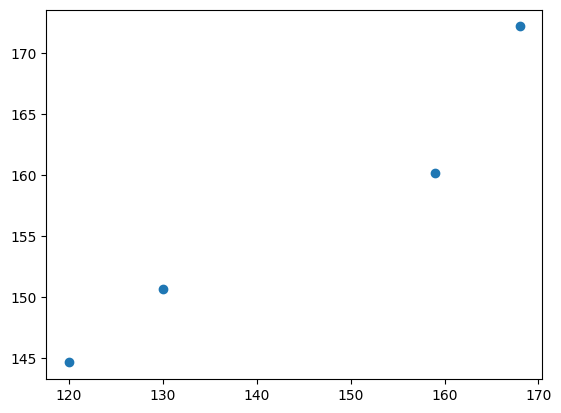

In [33]:
plt.scatter(y_test,y_pred)

In [35]:
#residuals
res=y_test-y_pred
print(res)

0    -24.627973
5     -4.150911
11    -1.184416
1    -20.611220
Name: Height, dtype: float64


C:\Users\RAJDEEP\AppData\Local\Temp\ipykernel_10652\3674099099.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

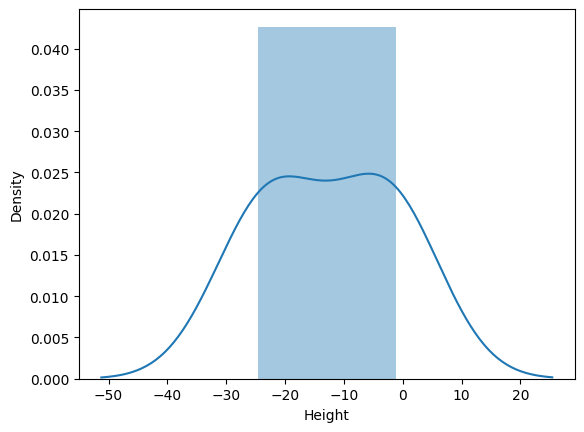

In [36]:
import seaborn as sns
sns.distplot(res,kde=True)

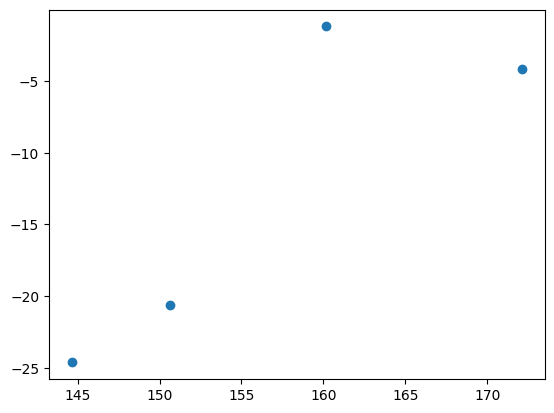

In [37]:
plt.scatter(y_pred,res)